<a href="https://colab.research.google.com/github/Kabilesh006/DEEPLEARNING/blob/main/RNN_Text_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EXPERIMENT 5
# IMPLEMENTATION OF A RECURRENT NEURAL NETWORK (RNN) FOR TEXT GENERATION



In [25]:
# Install required packageS
!pip install -q datasets tensorflow matplotlib numpy scikit-learn


In [26]:
print("24BAD051")
print("Kabileshwaran J")

24BAD051
Kabileshwaran J


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

from datasets import load_dataset

import random

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## PART A: Dataset Preparation

### A.1 Load the Tiny Shakespeare dataset from Hugging Face

In [28]:
dataset = load_dataset("Trelis/tiny-shakespeare")
dataset


DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})

### A.2 Explore the dataset and examine text samples

In [29]:
print("Splits available:", dataset.keys())
print()
print("Number of training examples:", len(dataset['train']))
print()
print("Sample record keys:", dataset['train'][0].keys())
print()
print("--- Sample text (first 500 chars) ---")
sample = dataset['train'][0]
sample_text = sample['Text'] if 'Text' in sample else list(sample.values())[0]
print(sample_text[:500])


Splits available: dict_keys(['train', 'test'])

Number of training examples: 472

Sample record keys: dict_keys(['Text'])

--- Sample text (first 500 chars) ---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [30]:
# Combine all training text into a single corpus string
column_name = 'Text' if 'Text' in dataset['train'].column_names else dataset['train'].column_names[0]
print("Using column:", column_name)

raw_text = "\n".join(dataset['train'][column_name])
print("Total characters in corpus:", len(raw_text))
print()
print(raw_text[:1000])


Using column: Text
Total characters in corpus: 1222825

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
spea

### A.3 Convert text to lowercase

For this experiment we use a manageable subset of the corpus so that training completes in reasonable time
on a CPU/GPU in a classroom setting. Increase `CORPUS_CHAR_LIMIT` if you have more compute available.

In [31]:
CORPUS_CHAR_LIMIT = 100_000  # adjust based on available compute

corpus = raw_text[:CORPUS_CHAR_LIMIT].lower()
print("Corpus length used:", len(corpus))
print(corpus[:500])


Corpus length used: 100000
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


### A.4 Tokenize the text into individual words & A.5 Build vocabulary

In [32]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token (index 0)
print("Vocabulary size:", vocab_size)

# Peek at a few word -> index mappings
sample_words = list(tokenizer.word_index.items())[:15]
print("Sample word->index mappings:", sample_words)


Vocabulary size: 2827
Sample word->index mappings: [('the', 1), ('you', 2), ('to', 3), ('and', 4), ('i', 5), ('of', 6), ('he', 7), ('a', 8), ('that', 9), ('in', 10), ('not', 11), ('your', 12), ('have', 13), ('his', 14), ('for', 15)]


### A.6 Generate input sequences for next-word prediction

We build the classic "n-gram sequence" dataset used for next-word prediction:
for every line/sentence, we generate progressively longer prefixes, each prefix's
last word being the label to predict.

In [33]:
# Split corpus into lines/sentences for sequence generation
lines = [l for l in corpus.split("\n") if l.strip() != ""]
print("Number of lines:", len(lines))

input_sequences = []
for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[: i + 1]
        input_sequences.append(n_gram_sequence)

print("Total input sequences generated:", len(input_sequences))
print("Example sequence (token ids):", input_sequences[10])


Number of lines: 3241
Total input sequences generated: 14743
Example sequence (token ids): [2, 27]


### A.7 Apply sequence padding to obtain inputs of equal length

In [34]:
max_sequence_len = max(len(seq) for seq in input_sequences)
print("Max sequence length:", max_sequence_len)

# Cap the max length to keep training efficient; long tails are rare
MAX_SEQ_LEN_CAP = 20
max_sequence_len = min(max_sequence_len, MAX_SEQ_LEN_CAP)
print("Using max sequence length:", max_sequence_len)

input_sequences = [seq[-max_sequence_len:] for seq in input_sequences]  # truncate very long ones
padded_sequences = pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')

print("Padded sequences shape:", padded_sequences.shape)


Max sequence length: 13
Using max sequence length: 13
Padded sequences shape: (14743, 13)


In [35]:
# Split into predictors (X) and label (y) - last token of each sequence is the label
X = padded_sequences[:, :-1]
labels = padded_sequences[:, -1]

y = to_categorical(labels, num_classes=vocab_size)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (14743, 12)
y shape: (14743, 2827)


### A.8 Split the prepared sequences into training and validation datasets

In [36]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])


Training samples: 11794
Validation samples: 2949


## PART B: Implementing the RNN Model

### B.1 - B.3 Embedding -> SimpleRNN -> Dense (Softmax)

In [37]:
EMBEDDING_DIM = 100
RNN_UNITS = 150

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM),
    SimpleRNN(RNN_UNITS),
    Dense(vocab_size, activation='softmax')
])

# Explicitly build the model so summary() shows real output shapes and param counts
# (Keras 3 no longer auto-builds from `input_length`; it only builds on first call/fit)
model.build(input_shape=(None, max_sequence_len - 1))


### B.4 Compile the model

In [38]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


### B.5 Display the model architecture and summary

In [39]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 12, 100)        │       282,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 150)            │        37,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2827)           │       426,877 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747,227 (2.85 MB)

 Trainable params: 747,227 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

## PART C: Training & Comparison

### C.1 Train the RNN model & validate

In [19]:
EPOCHS = 30
BATCH_SIZE = 128

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.0388 - loss: 6.8300 - val_accuracy: 0.0461 - val_loss: 6.6876
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0415 - loss: 6.3785 - val_accuracy: 0.0461 - val_loss: 6.7052
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0471 - loss: 6.1870 - val_accuracy: 0.0580 - val_loss: 6.6953
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0527 - loss: 6.0077 - val_accuracy: 0.0566 - val_loss: 6.6998
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0572 - loss: 5.8515 - val_accuracy: 0.0610 - val_loss: 6.7005
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0618 - loss: 5.7121 - val_accuracy: 0.0610 - val_loss: 6.7278


### C.2 Record final training/validation accuracy & loss

In [20]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy:   {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss:       {final_train_loss:.4f}")
print(f"Final Validation Loss:     {final_val_loss:.4f}")


Final Training Accuracy:   0.0618
Final Validation Accuracy: 0.0610
Final Training Loss:       5.7121
Final Validation Loss:     6.7278


### C.3 Visualize Accuracy vs Epoch and Loss vs Epoch

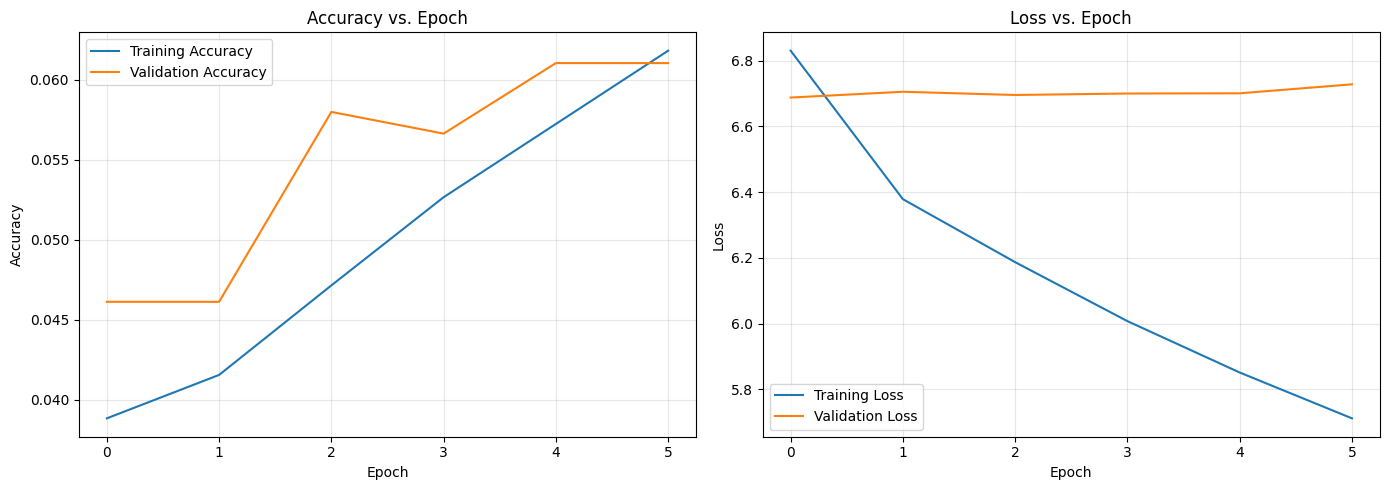

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy vs. Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss vs. Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


## PART D: Deep Learning Experiment Management — Text Generation

### D.1 - D.2 Generate text from a seed word/sentence by repeatedly predicting the next word

In [22]:
def generate_text(seed_text, next_words=30, model=model, tokenizer=tokenizer, max_sequence_len=max_sequence_len, temperature=1.0):
    """
    Generate text starting from seed_text by repeatedly predicting the next word.

    temperature < 1.0 -> more conservative / deterministic
    temperature > 1.0 -> more random / creative
    """
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = token_list[-(max_sequence_len - 1):]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')

        preds = model.predict(token_list, verbose=0)[0]

        # Apply temperature sampling
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        predicted_index = np.random.choice(len(preds), p=preds)

        output_word = tokenizer.index_word.get(predicted_index, '')
        if output_word == '':
            break
        result += ' ' + output_word

    return result


### D.3 Produce multiple text samples using different seed inputs

In [23]:
seed_words = ["to be", "the king", "love is", "what say", "my lord"]

generated_samples = {}
for seed in seed_words:
    generated = generate_text(seed, next_words=25, temperature=0.8)
    generated_samples[seed] = generated
    print(f"Seed: '{seed}'")
    print(f"Generated: {generated}")
    print("-" * 80)


Seed: 'to be'
Generated: to be be wager death 'tis and and the counsels nor general the flung revenge a of of beneath wrench verily his pray above 'though as all
--------------------------------------------------------------------------------
Seed: 'the king'
Generated: the king become he good rome the own of the charter expedition toge for you again me manifest filling the unborn fortnight up for would was of
--------------------------------------------------------------------------------
Seed: 'love is'
Generated: love is tonight kind seeking hector lartius notice you he the with they have stands is your from and return you road unaching he the shut alone
--------------------------------------------------------------------------------
Seed: 'what say'
Generated: what say bring flatter you be to he'll who it the it it show these rash do to honour wherein upon proceed endure would but the to
--------------------------------------------------------------------------------
Seed: 'my lord

### D.4 Compare generated text for coherence and contextual relevance



In [24]:
for seed, text in generated_samples.items():
    print(f"Seed: {seed!r}")
    print(f"  -> {text}")
    print()

# TODO (student): For each sample above, note:
#  - Does the generated text follow grammatical patterns seen in Shakespearean English?
#  - Does it stay contextually relevant to the seed, or drift into unrelated topics?
#  - Are there repeated word loops (a common SimpleRNN failure mode)?


Seed: 'to be'
  -> to be be wager death 'tis and and the counsels nor general the flung revenge a of of beneath wrench verily his pray above 'though as all

Seed: 'the king'
  -> the king become he good rome the own of the charter expedition toge for you again me manifest filling the unborn fortnight up for would was of

Seed: 'love is'
  -> love is tonight kind seeking hector lartius notice you he the with they have stands is your from and return you road unaching he the shut alone

Seed: 'what say'
  -> what say bring flatter you be to he'll who it the it it show these rash do to honour wherein upon proceed endure would but the to

Seed: 'my lord'
  -> my lord the am it good wont in marcius after that you instruct and 'brutus patrician own 'twixt wounded of west was fall buy his to that

